## Setup

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from itertools import compress 
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV,StratifiedKFold

In [87]:
%matplotlib inline

dataset_location = "E:\GIT\Vitreus\data\datasets\dataset_A.xlsx"
df_raw = pd.read_excel(dataset_location)

y = df_raw['diagnostico_bin']

x_raw = df_raw.drop(['diagnostico', 'diagnostico_bin','cod_exame', 'id_paciente'], axis=1)

x_norm_select = pd.DataFrame(preprocessing.normalize(df_raw.drop(['diagnostico', 'diagnostico_bin','cod_exame', 'id_paciente'], axis=1),axis=0),columns = [i+'_norm' for i in x_raw.columns])

df = pd.concat([df_raw,x_norm_select],axis=1)

x_norm_and_raw = df.drop(['diagnostico', 'diagnostico_bin','cod_exame', 'id_paciente'], axis=1)
# parametros = df.drop(columns=['id_paciente']).columns
# sns.pairplot(data=df[parametros],hue='diagnostico')

## Seleção de váriaveis

### analise normalizada

In [16]:
import pandas as pd
from numpy import sort
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.svm import SVC

#### matriz de correlação

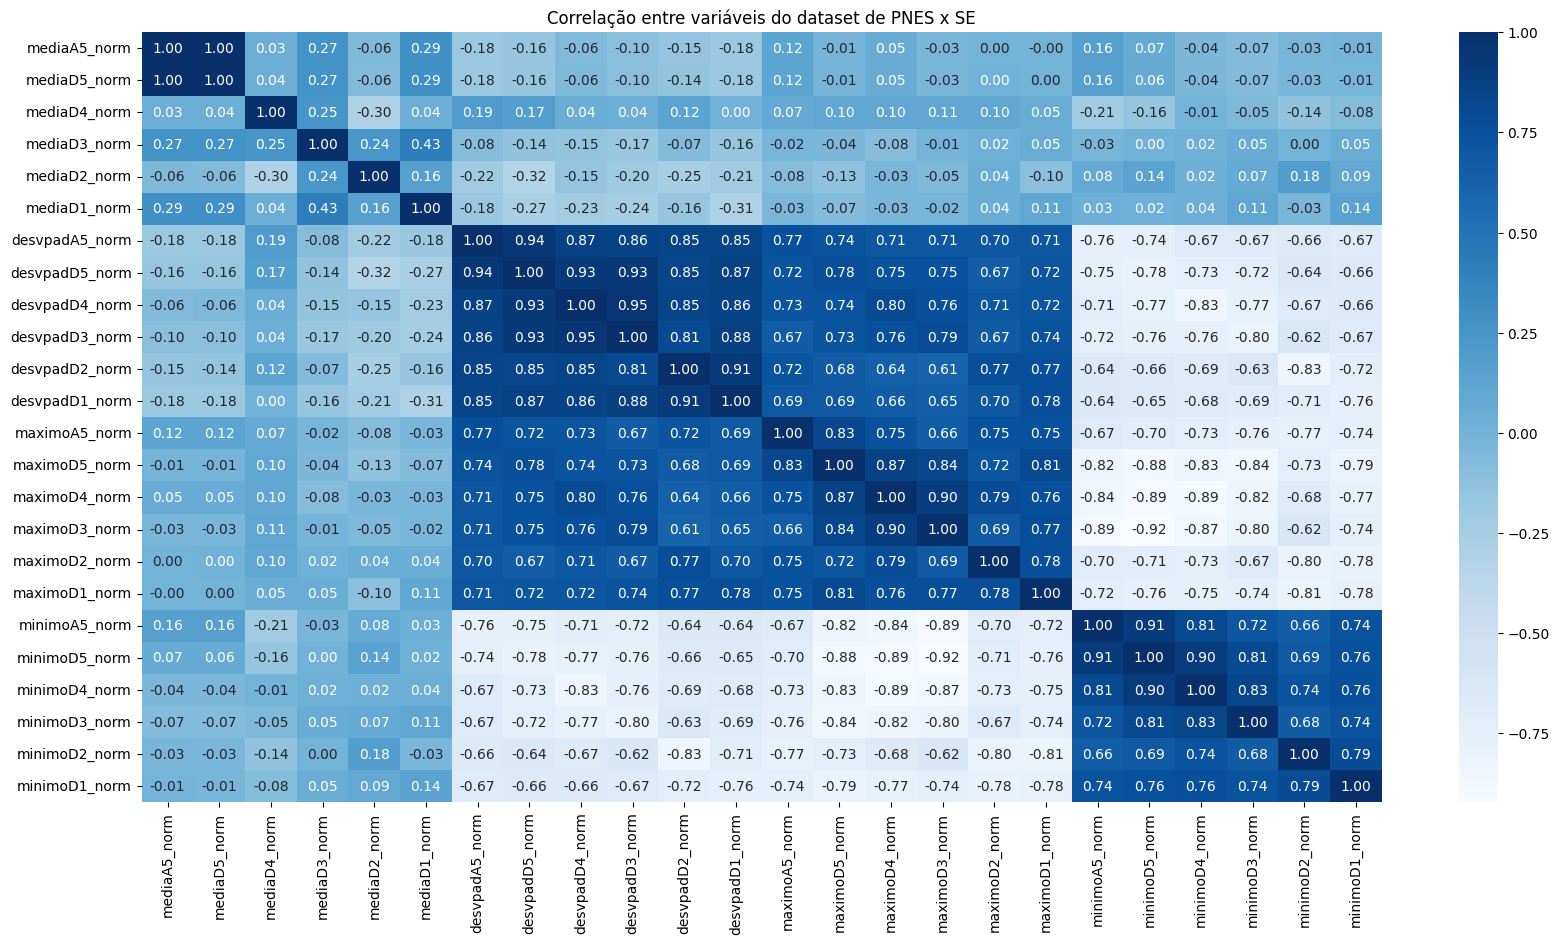

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20, 10))
sns.heatmap(x_norm_select.corr(),
            annot = True,
            fmt = '.2f',
            cmap='Blues')
plt.title('Correlação entre variáveis do dataset de PNES x SE')
plt.show()

In [89]:
x.corr().where(abs(x.corr()) > 0.5).stack().reset_index().rename(columns={0: 'correlation', 'level_0': 'feature1', 'level_1': 'feature2'}).query('feature1 != feature2').sort_values(by='correlation', ascending=False)

,feature1,feature2,correlation
1,mediaA5,mediaD5,0.999766
2,mediaD5,mediaA5,0.999766
64,desvpadD3,desvpadD4,0.950453
47,desvpadD4,desvpadD3,0.950453
9,desvpadA5,desvpadD5,0.942056
...,...,...,...
182,maximoD3,minimoA5,-0.893292
165,maximoD4,minimoD5,-0.894023
250,minimoD5,maximoD4,-0.894023
183,maximoD3,minimoD5,-0.922181


In [90]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt 

def plot_coefficients(classifier, feature_names, top_features=20):
    coef = classifier.coef_
    top_positive_coefficients = np.argsort(coef)[-top_features:]
    top_negative_coefficients = np.argsort(coef)[:top_features]
    top_coefficients = np.hstack([top_negative_coefficients, top_positive_coefficients])
    # create plot
    plt.figure(figsize=(15, 5))
    colors = ['red' if c < 0 else 'blue' for c in coef[top_coefficients]]
    plt.bar(np.arange(2 * top_features), coef[top_coefficients], color=colors)
    feature_names = np.array(feature_names)
    plt.xticks(np.arange(1, 1 + 2 * top_features), feature_names[top_coefficients], rotation=60, ha='right')
    plt.show()
    cv = CountVectorizer()
    cv.fit(x_norm_select)
    print (len(cv.vocabulary_))
    print (cv.get_feature_names())
    X_train = cv.transform(x_norm_select)

    svm = LinearSVC()
    svm.fit(X_train, target)
    plot_coefficients(svm, cv.get_feature_names())

#### treino sem nenhum tratamento de features

In [ ]:
import numpy as np
from collections import Counter
roc_auc_list = []

# Loop para rodar 30 vezes
for i in range(100):
    # Separa os dados em treino e teste (33% para teste)
    X_train, X_test, y_train, y_test = train_test_split(
        x_norm_select, y, test_size=0.33, random_state=i
    )

    # Define o balanceamento das classes para o SVM
    balanceamento = {1: 1.8, 0: 1}

    # Cria o classificador SVM com kernel RBF e balanceamento de classes
    svc = svm.SVC(kernel='rbf', class_weight=balanceamento)

    # Treina o modelo SVM
    svc.fit(X_train, y_train)

    # Obtém os scores de decisão do SVM para o conjunto de teste
    y_scores = svc.decision_function(X_test)

    # Calcula a métrica ROC AUC usando os scores de decisão
    roc_auc = roc_auc_score(y_test, y_scores)
    roc_auc_list.append(roc_auc)

# Calcula menor, maior e o valor mais frequente (moda)
menor = np.min(roc_auc_list)
maior = np.max(roc_auc_list)
mais_frequente = Counter(np.round(roc_auc_list, 4)).most_common(1)[0][0]

print(f"Menor ROC AUC: {menor:.4f}")
print(f"Maior ROC AUC: {maior:.4f}")
print(f"Valor mais frequente de ROC AUC: {mais_frequente:.4f}")
print(f"media ROC AUC: {np.mean(roc_auc_list):.4f}")

Menor ROC AUC: 0.4701
Maior ROC AUC: 0.9279
Valor mais frequente de ROC AUC: 0.7039
media ROC AUC: 0.7350


#### treino selecionando features da permutação de importancia

Text(0.5, 0, 'Permutation Importance')

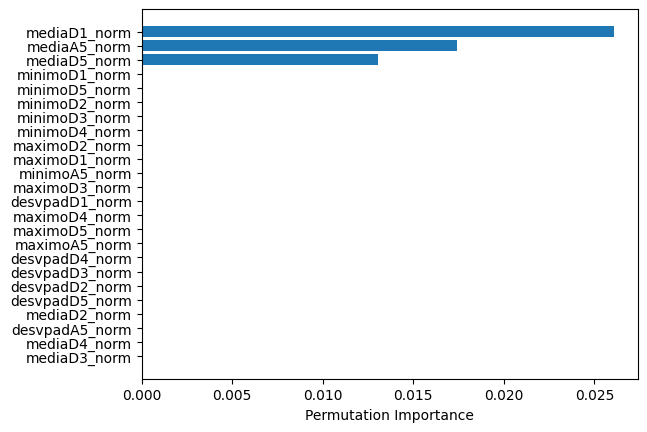

In [97]:
X_train, X_test, y_train, y_test = train_test_split(x_norm_select, y, test_size=0.33, random_state=42)
perm_importance = permutation_importance(svc, X_test, y_test)

features = np.array(list(x_norm_select.columns))

sorted_idx = perm_importance.importances_mean.argsort()
plt.barh(features[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")

In [98]:
features_filtradas = list(compress(features  , ((perm_importance.importances_mean > 0.01)  | (perm_importance.importances_mean < -0.01))))
features_filtradas = [str(f) for f in features_filtradas]
print(features_filtradas)

['mediaA5_norm', 'mediaD5_norm', 'mediaD1_norm']


In [99]:
import numpy as np
from collections import Counter
roc_auc_list = []

# Loop para rodar 30 vezes
for i in range(100):
    # Separa os dados em treino e teste (33% para teste)
    X_train, X_test, y_train, y_test = train_test_split(
        x_norm_select[features_filtradas], y, test_size=0.33)

    # Define o balanceamento das classes para o SVM
    balanceamento = {1: 1.8, 0: 1}

    # Cria o classificador SVM com kernel RBF e balanceamento de classes
    svc = svm.SVC(kernel='rbf', class_weight=balanceamento)

    # Treina o modelo SVM
    svc.fit(X_train, y_train)

    # Obtém os scores de decisão do SVM para o conjunto de teste
    y_scores = svc.decision_function(X_test)

    # Calcula a métrica ROC AUC usando os scores de decisão
    roc_auc = roc_auc_score(y_test, y_scores)
    roc_auc_list.append(roc_auc)

# Calcula menor, maior e o valor mais frequente (moda)
menor = np.min(roc_auc_list)
maior = np.max(roc_auc_list)
mais_frequente = Counter(np.round(roc_auc_list, 4)).most_common(1)[0][0]

print(f"Menor ROC AUC: {menor:.4f}")
print(f"Maior ROC AUC: {maior:.4f}")
print(f"Valor mais frequente de ROC AUC: {mais_frequente:.4f}")
print(f"media ROC AUC: {np.mean(roc_auc_list):.4f}")

Menor ROC AUC: 0.5469
Maior ROC AUC: 0.9405
Valor mais frequente de ROC AUC: 0.7500
media ROC AUC: 0.7237


#### treino selecionando features usando step foward

In [2]:
X_train, X_test, y_train, y_test = train_test_split(x_norm_select, y, test_size=0.33)

sfs = SequentialFeatureSelector(estimator=svc, n_features_to_select=5, direction='forward')
sfs.fit(X_train, y_train)

# Selected feature indices
selected_features_fast_foward = list(sfs.get_support(indices=True))
selected_features_fast_foward_name = x_norm_select.iloc[:,selected_features_fast_foward].columns

x_norm_select.iloc[:,selected_features_fast_foward], selected_features_fast_foward_name

NameError: name 'train_test_split' is not defined

In [117]:
selected_features_fast_foward_name
selected_features_fast_foward_name_tratadas = [str(f).replace('_norm', '') for f in selected_features_fast_foward_name]
selected_features_fast_foward_name_tratadas

['mediaD2', 'desvpadD1', 'maximoA5', 'maximoD5', 'maximoD1']

In [104]:
roc_auc_list = []

# Loop para rodar 30 vezes
for i in range(100):
    # Separa os dados em treino e teste (33% para teste)
    X_train, X_test, y_train, y_test = train_test_split(
        x_norm_select[selected_features_fast_foward_name], y, test_size=0.33)

    # Define o balanceamento das classes para o SVM
    balanceamento = {1: 1.8, 0: 1}

    # Cria o classificador SVM com kernel RBF e balanceamento de classes
    svc = svm.SVC(kernel='rbf', class_weight=balanceamento)

    # Treina o modelo SVM
    svc.fit(X_train, y_train)

    # Obtém os scores de decisão do SVM para o conjunto de teste
    y_scores = svc.decision_function(X_test)

    # Calcula a métrica ROC AUC usando os scores de decisão
    roc_auc = roc_auc_score(y_test, y_scores)
    roc_auc_list.append(roc_auc)

# Calcula menor, maior e o valor mais frequente (moda)
menor = np.min(roc_auc_list)
maior = np.max(roc_auc_list)
mais_frequente = Counter(np.round(roc_auc_list, 4)).most_common(1)[0][0]

print(f"Menor ROC AUC: {menor:.4f}")
print(f"Maior ROC AUC: {maior:.4f}")
print(f"Valor mais frequente de ROC AUC: {mais_frequente:.4f}")
print(f"media ROC AUC: {np.mean(roc_auc_list):.4f}")

Menor ROC AUC: 0.4944
Maior ROC AUC: 0.9806
Valor mais frequente de ROC AUC: 0.8527
media ROC AUC: 0.7512


### analise não normalizada 

In [105]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)
balanceamento = {1: 1.8, 0: 1}

svc = svm.SVC(kernel='poly', class_weight=balanceamento)
svc.fit(X_train, y_train)
from sklearn.metrics import roc_auc_score
y_scores = svc.decision_function(X_test)
roc_auc = roc_auc_score(y_test, y_scores)
print("ROC AUC:", roc_auc)

ROC AUC: 0.5379464285714286


Text(0.5, 0, 'Permutation Importance')

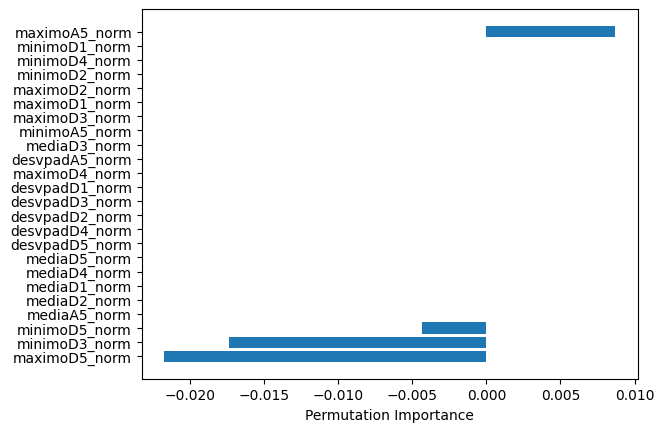

In [106]:
perm_importance = permutation_importance(svc, X_test, y_test)

features = np.array(list(x_norm_select.columns))

sorted_idx = perm_importance.importances_mean.argsort()
plt.barh(features[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")

In [107]:
sfs = SequentialFeatureSelector(estimator=svc, n_features_to_select=5, direction='forward')
sfs.fit(X_train, y_train)

# Selected feature indices
selected_features = list(sfs.get_support(indices=True))

x.iloc[:,selected_features], x.iloc[:,selected_features].columns

(          mediaD5    mediaD4    mediaD3     mediaD1    desvpadD1
 0   -1.180792e-13 -54.751338  39.329875  -40.954451   666.281552
 1   -1.507061e-13 -37.706197 -37.293552 -255.886461   699.744054
 2    6.902339e-14 -68.429380  11.218299  -79.050710  1008.932371
 3   -9.217408e-14  -1.380568 -72.373312 -214.095893   662.471105
 4    1.283355e-14 -55.112087  28.521332   -8.247332  1232.246285
 ..            ...        ...        ...         ...          ...
 134 -2.402025e-16   1.187820   1.517382   -3.501996   626.608116
 135  1.203747e-15  -9.840589  -1.470042  -24.372327   305.657247
 136 -2.649129e-14  13.908952  -4.970163  -26.968734   433.856077
 137 -5.427786e-16   2.051034  -5.564086  -27.294977    72.772628
 138 -2.341496e-14  32.436031   7.872192  -86.711260   455.270811
 
 [139 rows x 5 columns],
 Index(['mediaD5', 'mediaD4', 'mediaD3', 'mediaD1', 'desvpadD1'], dtype='object'))

## Otimização de Hiperparametros

In [133]:
gamma_range = np.logspace(-3, 1, 10)
C_range = np.logspace(-1,3,10)
parameters = {'kernel':('linear', 'rbf','poly','sigmoid'),
              'cache_size':[2000],
              'class_weight': ['balanced', {1:2,0:1}, {1:3,0:1}, {1:3.5,0:1}],
              'gamma': gamma_range,
              'C':C_range}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [134]:
#dataset A
clf = GridSearchCV(svm.SVC(), parameters, scoring='roc_auc', cv=cv,n_jobs=-1)
svc = svm.SVC()
x_norm_ff = preprocessing.normalize(df_raw.drop(['diagnostico', 'diagnostico_bin','cod_exame', 'id_paciente'], axis=1)[selected_features_fast_foward_name_tratadas],axis=0)
clf.fit(x_norm_ff,y)
result = pd.DataFrame(clf.cv_results_)
result[result.rank_test_score == 1]['params'].values , result[result.rank_test_score == 1]['mean_test_score'].values

(array([{'C': np.float64(1000.0), 'cache_size': 2000, 'class_weight': {1: 2, 0: 1}, 'gamma': np.float64(3.593813663804626), 'kernel': 'rbf'}],
       dtype=object),
 array([0.79284014]))

In [136]:
#dataset B
clf_B = GridSearchCV(svm.SVC(), parameters, scoring='roc_auc', cv=cv,n_jobs=-1)
svc = svm.SVC()
clf_B.fit(x_norm_select, y)
result_B = pd.DataFrame(clf_B.cv_results_)
result_B[result_B.rank_test_score == 1]['params'].values , result_B[result_B.rank_test_score == 1]['mean_test_score'].values

(array([{'C': np.float64(16.68100537200059), 'cache_size': 2000, 'class_weight': {1: 2, 0: 1}, 'gamma': np.float64(1.2915496650148828), 'kernel': 'rbf'}],
       dtype=object),
 array([0.77565476]))

In [137]:
result.sort_values('rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_cache_size,param_class_weight,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1513,0.004910,0.001400,0.002202,0.000400,1000.000000,2000,"{1: 2, 0: 1}",3.593814,rbf,"{'C': 1000.0, 'cache_size': 2000, 'class_weigh...",0.69375,0.90000,0.86875,0.823129,0.678571,0.792840,0.090597,1
1237,0.003006,0.000835,0.003105,0.001959,129.154967,2000,"{1: 3, 0: 1}",10.000000,rbf,"{'C': 129.15496650148827, 'cache_size': 2000, ...",0.71875,0.87500,0.79375,0.850340,0.678571,0.783282,0.075030,2
1277,0.003620,0.001764,0.004605,0.002060,129.154967,2000,"{1: 3.5, 0: 1}",10.000000,rbf,"{'C': 129.15496650148827, 'cache_size': 2000, ...",0.74375,0.87500,0.78750,0.850340,0.650000,0.781318,0.080292,3
1593,0.004410,0.001165,0.002406,0.000375,1000.000000,2000,"{1: 3.5, 0: 1}",3.593814,rbf,"{'C': 1000.0, 'cache_size': 2000, 'class_weigh...",0.70625,0.88125,0.78750,0.850340,0.671429,0.779354,0.080598,4
1197,0.007626,0.004818,0.008822,0.005330,129.154967,2000,"{1: 2, 0: 1}",10.000000,rbf,"{'C': 129.15496650148827, 'cache_size': 2000, ...",0.66250,0.89375,0.85625,0.823129,0.650000,0.777126,0.101270,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1082,0.001605,0.000377,0.002305,0.000603,46.415888,2000,"{1: 3.5, 0: 1}",0.001000,poly,"{'C': 46.41588833612777, 'cache_size': 2000, '...",0.57500,0.50000,0.60000,0.680272,0.164286,0.503912,0.179305,1590
602,0.003921,0.001822,0.003452,0.001807,2.154435,2000,"{1: 3.5, 0: 1}",0.001000,poly,"{'C': 2.1544346900318834, 'cache_size': 2000, ...",0.58750,0.50000,0.57500,0.680272,0.164286,0.501412,0.178030,1597
126,0.001004,0.000008,0.001503,0.000636,0.100000,2000,"{1: 3.5, 0: 1}",0.002783,poly,"{'C': 0.1, 'cache_size': 2000, 'class_weight':...",0.58750,0.50000,0.57500,0.680272,0.164286,0.501412,0.178030,1597
282,0.002305,0.000402,0.003607,0.002267,0.278256,2000,"{1: 3.5, 0: 1}",0.001000,poly,"{'C': 0.2782559402207124, 'cache_size': 2000, ...",0.57500,0.50000,0.57500,0.687075,0.164286,0.500272,0.178298,1599


In [138]:
result_B.sort_values('rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_cache_size,param_class_weight,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
869,0.004313,0.000820,0.005206,0.001575,16.681005,2000,"{1: 2, 0: 1}",1.291550,rbf,"{'C': 16.68100537200059, 'cache_size': 2000, '...",0.63750,0.81250,0.96875,0.809524,0.650000,0.775655,0.122202,1
1581,0.004308,0.000511,0.003607,0.000584,1000.000000,2000,"{1: 3.5, 0: 1}",0.166810,rbf,"{'C': 1000.0, 'cache_size': 2000, 'class_weigh...",0.83125,0.76250,0.84375,0.659864,0.764286,0.772330,0.065395,2
1185,0.003813,0.000520,0.003203,0.000247,129.154967,2000,"{1: 2, 0: 1}",0.464159,rbf,"{'C': 129.15496650148827, 'cache_size': 2000, ...",0.67500,0.77500,0.93125,0.782313,0.678571,0.768427,0.093327,3
1501,0.004420,0.000600,0.005007,0.002532,1000.000000,2000,"{1: 2, 0: 1}",0.166810,rbf,"{'C': 1000.0, 'cache_size': 2000, 'class_weigh...",0.73750,0.80000,0.86875,0.768707,0.657143,0.766420,0.069831,4
1225,0.003710,0.000607,0.002903,0.000663,129.154967,2000,"{1: 3, 0: 1}",0.464159,rbf,"{'C': 129.15496650148827, 'cache_size': 2000, ...",0.74375,0.81875,0.83750,0.693878,0.700000,0.758776,0.059475,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
639,0.003306,0.000403,0.003003,0.000315,2.154435,2000,"{1: 3.5, 0: 1}",10.000000,sigmoid,"{'C': 2.1544346900318834, 'cache_size': 2000, ...",0.41875,0.53125,0.65625,0.462585,0.221429,0.458053,0.142966,1596
439,0.002804,0.000243,0.004110,0.000489,0.774264,2000,"{1: 3, 0: 1}",10.000000,sigmoid,"{'C': 0.774263682681127, 'cache_size': 2000, '...",0.46250,0.56875,0.61875,0.442177,0.178571,0.454150,0.152567,1597
599,0.002806,0.000676,0.003102,0.000202,2.154435,2000,"{1: 3, 0: 1}",10.000000,sigmoid,"{'C': 2.1544346900318834, 'cache_size': 2000, ...",0.43750,0.46875,0.65625,0.482993,0.221429,0.453384,0.138797,1598
519,0.006512,0.005284,0.004204,0.002162,2.154435,2000,balanced,10.000000,sigmoid,"{'C': 2.1544346900318834, 'cache_size': 2000, ...",0.43750,0.49375,0.62500,0.482993,0.178571,0.443563,0.146458,1599


In [140]:
selected_features_fast_foward_name_tratadas

['mediaD2', 'desvpadD1', 'maximoA5', 'maximoD5', 'maximoD1']

In [139]:
clf.best_params_

{'C': np.float64(1000.0),
 'cache_size': 2000,
 'class_weight': {1: 2, 0: 1},
 'gamma': np.float64(3.593813663804626),
 'kernel': 'rbf'}

In [ ]:
clf_B.best_params_

{'C': np.float64(278.2559402207126),
 'cache_size': 2000,
 'class_weight': 'balanced',
 'gamma': np.float64(0.464158883361278),
 'kernel': 'rbf'}